In [1]:
!pip install -q kagglehub opencv-python seaborn scikit-learn

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import load_img, img_to_array

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


In [3]:
print("GPU devices:")

for device in tf.config.list_physical_devices("GPU"):
    print(device)

GPU devices:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [4]:
dataset_path = kagglehub.dataset_download(
    "muhriddinmuxiddinov/fruits-and-vegetables-dataset"
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 870M/870M [00:09<00:00, 92.7MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2


In [5]:
print(os.listdir(dataset_path))

['Fruits_Vegetables_Dataset(12000)']


In [6]:
dataset_root = os.path.join(
    dataset_path,
    "Fruits_Vegetables_Dataset(12000)"
)

print(os.listdir(dataset_root))

['Fruits', 'Vegetables']


In [7]:
fruits_path = os.path.join(
    dataset_root,
    "Fruits"
)

vegetables_path = os.path.join(
    dataset_root,
    "Vegetables"
)

print("Fruits:")
print(os.listdir(fruits_path))

print("\nVegetables:")
print(os.listdir(vegetables_path))

Fruits:
['RottenOrange', 'RottenBanana', 'FreshBanana', 'RottenStrawberry', 'FreshOrange', 'FreshMango', 'RottenApple', 'FreshStrawberry', 'RottenMango', 'FreshApple']

Vegetables:
['RottenCucumber', 'FreshCarrot', 'FreshTomato', 'RottenTomato', 'RottenCarrot', 'RottenPotato', 'FreshCucumber', 'FreshBellpepper', 'RottenBellpepper', 'FreshPotato']


In [8]:
for class_name in os.listdir(fruits_path):

    class_path = os.path.join(
        fruits_path,
        class_name
    )

    if os.path.isdir(class_path):

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

        print(class_name, ":", count, "images")

RottenOrange : 591 images
RottenBanana : 573 images
FreshBanana : 623 images
RottenStrawberry : 596 images
FreshOrange : 609 images
FreshMango : 605 images
RottenApple : 583 images
FreshStrawberry : 603 images
RottenMango : 593 images
FreshApple : 612 images


In [9]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 123

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    fruits_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Training dataset created!")

Found 5988 files belonging to 10 classes.
Using 4791 files for training.
Training dataset created!


In [11]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    fruits_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Validation dataset created!")

Found 5988 files belonging to 10 classes.
Using 1197 files for validation.
Validation dataset created!


In [12]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['FreshApple', 'FreshBanana', 'FreshMango', 'FreshOrange', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenMango', 'RottenOrange', 'RottenStrawberry']


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(
    1000
).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset optimization completed!")

Dataset optimization completed!


In [14]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully!


In [15]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

print("Model created successfully!")

Model created successfully!


In [16]:
model.build(
    input_shape=(None, 224, 224, 3)
)

print("Model built successfully!")

Model built successfully!


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [19]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_fruit_freshness_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Checkpoint created successfully!")

Checkpoint created successfully!


In [20]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[checkpoint]
)

Epoch 1/15
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.1891 - loss: 2.3953
Epoch 1: val_accuracy improved from None to 0.58730, saving model to best_fruit_freshness_model.keras

Epoch 1: finished saving model to best_fruit_freshness_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 234ms/step - accuracy: 0.3079 - loss: 1.9976 - val_accuracy: 0.5873 - val_loss: 1.3352
Epoch 2/15
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5989 - loss: 1.2363
Epoch 2: val_accuracy improved from 0.58730 to 0.77193, saving model to best_fruit_freshness_model.keras

Epoch 2: finished saving model to best_fruit_freshness_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6491 - loss: 1.1051 - val_accuracy: 0.7719 - val_loss: 0.8348
Epoch 3/15
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7715 - loss: 0.8016
Epoch 3: val_accuracy improved from 0.77193 to 0.85464, saving model to best_fruit_freshness_model.keras

Epoch 3: finished saving model to best_fruit_freshn

In [21]:
import os

print("Files in Colab:")
print(os.listdir("/content"))

Files in Colab:
['.config', 'best_fruit_freshness_model.keras', 'sample_data']


In [22]:
model_size = os.path.getsize(
    "/content/best_fruit_freshness_model.keras"
) / (1024 * 1024)

print(
    "Best model size:",
    round(model_size, 2),
    "MB"
)

Best model size: 9.32 MB


In [23]:
model.save(
    "/content/fruit_freshness_mobilenetv2.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


In [24]:
print("Best Training Accuracy:",
      max(history.history["accuracy"]) * 100)

print("Best Validation Accuracy:",
      max(history.history["val_accuracy"]) * 100)

print("Lowest Validation Loss:",
      min(history.history["val_loss"]))

Best Training Accuracy: 95.57503461837769
Best Validation Accuracy: 95.15455365180969
Lowest Validation Loss: 0.19382448494434357


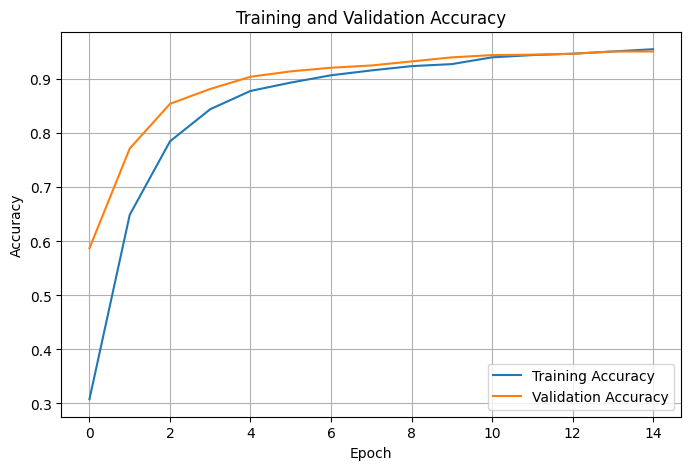

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

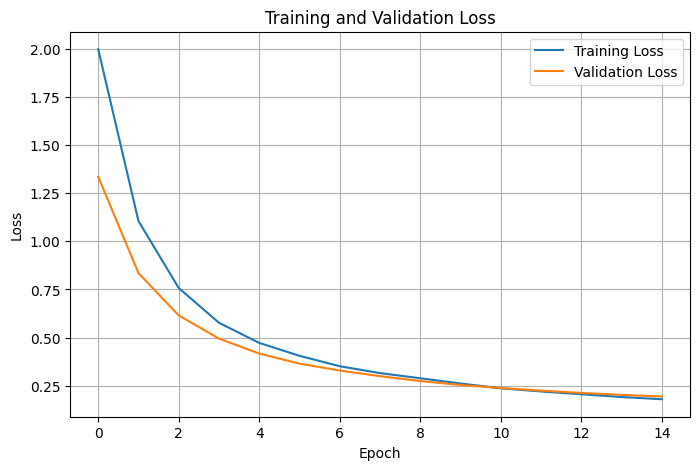

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

In [27]:
best_model = tf.keras.models.load_model(
    "/content/best_fruit_freshness_model.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [28]:
test_loss, test_accuracy = best_model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nFinal Validation Results")
print("-------------------------")
print(
    "Validation Loss:",
    round(test_loss, 4)
)

print(
    "Validation Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9515 - loss: 0.2021

Final Validation Results
-------------------------
Validation Loss: 0.2021
Validation Accuracy: 95.15 %


In [29]:
y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")
print("Number of validation images:", len(y_true))

Predictions generated successfully!
Number of validation images: 1197


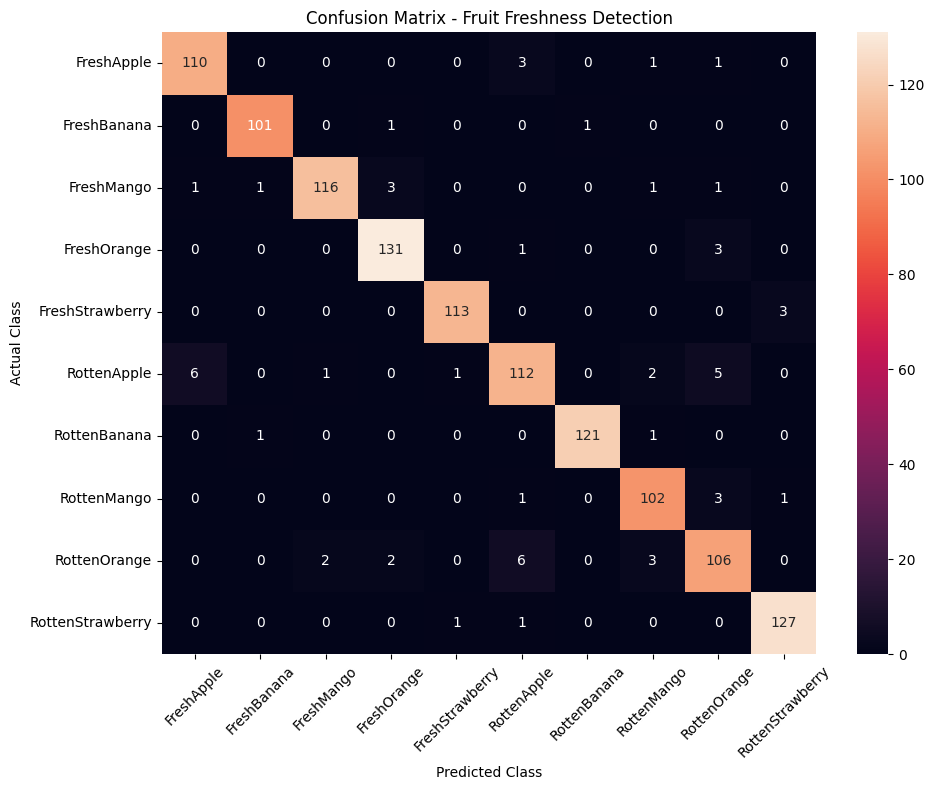

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - Fruit Freshness Detection"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [31]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                  precision    recall  f1-score   support

      FreshApple       0.94      0.96      0.95       115
     FreshBanana       0.98      0.98      0.98       103
      FreshMango       0.97      0.94      0.96       123
     FreshOrange       0.96      0.97      0.96       135
 FreshStrawberry       0.98      0.97      0.98       116
     RottenApple       0.90      0.88      0.89       127
    RottenBanana       0.99      0.98      0.99       123
     RottenMango       0.93      0.95      0.94       107
    RottenOrange       0.89      0.89      0.89       119
RottenStrawberry       0.97      0.98      0.98       129

        accuracy                           0.95      1197
       macro avg       0.95      0.95      0.95      1197
    weighted avg       0.95      0.95      0.95      1197



In [32]:
def predict_fruit(image_path):

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    predictions = best_model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(
        predictions[0]
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        predictions[0][predicted_index] * 100
    )

    if predicted_class.startswith("Fresh"):
        freshness = "Fresh"
    else:
        freshness = "Rotten"

    fruit_name = (
        predicted_class
        .replace("Fresh", "")
        .replace("Rotten", "")
    )

    print("================================")
    print("     FOOD FRESHNESS RESULT")
    print("================================")
    print("Fruit      :", fruit_name)
    print("Freshness  :", freshness)
    print(
        "Confidence :",
        round(confidence, 2),
        "%"
    )
    print("================================")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)

    plt.title(
        f"{fruit_name} - {freshness}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    return predicted_class, confidence

     FOOD FRESHNESS RESULT
Fruit      : Apple
Freshness  : Fresh
Confidence : 75.27 %


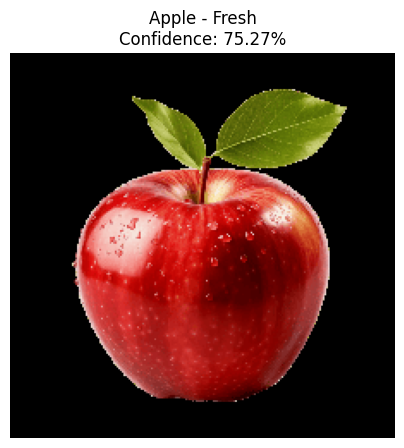

In [33]:
predicted_class, confidence = predict_fruit(
    "/content/fresh_apple.jpg"
)

In [34]:
base_model = best_model.get_layer(
    "mobilenetv2_1.00_224"
)

last_conv_layer = base_model.get_layer(
    "Conv_1"
)

print(
    "Last convolutional layer:",
    last_conv_layer.name
)

print(
    "Output shape:",
    last_conv_layer.output.shape
)

Last convolutional layer: Conv_1
Output shape: (None, 7, 7, 1280)


In [35]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        last_conv_layer.output,
        base_model.output
    ]
)

print("Grad-CAM model created successfully!")

Grad-CAM model created successfully!


In [36]:
image_path = "/content/fresh_apple.jpg"

img = load_img(
    image_path,
    target_size=(224, 224)
)

img_array = img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    0
)

print(
    "Input shape:",
    img_array.shape
)

Input shape: (1, 224, 224, 3)


In [37]:
with tf.GradientTape() as tape:

    conv_outputs, base_output = grad_model(
        img_array,
        training=False
    )

    x = base_output

    x = best_model.get_layer(
        "global_average_pooling2d"
    )(x)

    x = best_model.get_layer(
        "dropout"
    )(x, training=False)

    predictions = best_model.get_layer(
        "dense"
    )(x)

    predicted_index = tf.argmax(
        predictions[0]
    )

    predicted_output = predictions[
        :, predicted_index
    ]

grads = tape.gradient(
    predicted_output,
    conv_outputs
)

print("Gradients calculated successfully!")

Gradients calculated successfully!


In [38]:
conv_outputs = conv_outputs[0]
grads = grads[0]

weights = tf.reduce_mean(
    grads,
    axis=(0, 1)
)

cam = tf.reduce_sum(
    conv_outputs * weights,
    axis=-1
)

cam = tf.maximum(
    cam,
    0
)

cam = cam / (
    tf.reduce_max(cam)
    + tf.keras.backend.epsilon()
)

heatmap = cam.numpy()

print(
    "Heatmap created successfully!"
)

print(
    "Heatmap shape:",
    heatmap.shape
)

Heatmap created successfully!
Heatmap shape: (7, 7)


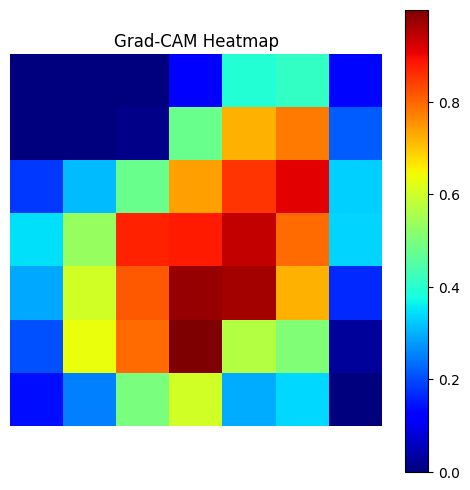

In [39]:
plt.figure(figsize=(6, 6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title(
    "Grad-CAM Heatmap"
)

plt.axis("off")

plt.show()

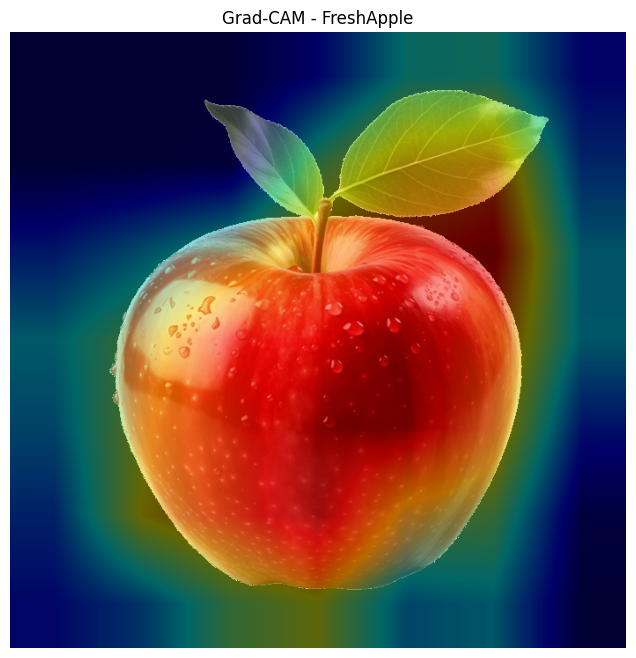

In [40]:
original_img = cv2.imread(
    image_path
)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (
        original_img.shape[1],
        original_img.shape[0]
    )
)

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    f"Grad-CAM - {predicted_class}"
)

plt.axis("off")

plt.show()